In [17]:
#  CC3074 – Minería de Datos
#  Proyecto 3. Avances 2. Antecedentes y selección de algoritmos
# 
#  Integrantes del grupo:
#  Diego Sandoval - 231977
#  Jorge Gabriel Palacios Sales - 231385
#  Anggelie Lizeth Velásquez Asencio - 221181
#  Roberto Camposeco Torres – 23968 

In [1]:
# Imports globales compartidos por todos los módulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
SEED = 42

In [2]:

# Configuración de las rutas

BASE_DIR = os.getcwd()

RUTAS = {
    'MATRIMONIOS': os.path.join(BASE_DIR, 'data_matrimonios'),
    'DIVORCIOS':   os.path.join(BASE_DIR, 'data_divorcios')
}

MAPA_COLUMNAS = {
    'A_OCUR':   'ANIO_OCURRENCIA',
    'MES_OCUR': 'MES_OCURRENCIA',
    'DEPTO':    'DEPARTAMENTO',
    'MUN':      'MUNICIPIO',
    'EDADHOM':  'EDAD_HOMBRE',
    'EDADMUJ':  'EDAD_MUJER',
    'ESCHOM':   'ESCOLARIDAD_HOMBRE',
    'ESCMUJ':   'ESCOLARIDAD_MUJER',
    'PUEHOM':   'PUEBLO_HOMBRE',
    'PUEMUJ':   'PUEBLO_MUJER',
    'NACHOM':   'NACIONALIDAD_HOMBRE',
    'NACMUJ':   'NACIONALIDAD_MUJER',
    'CIUOHOM':  'OCUPACION_HOMBRE',
    'CIUOMUJ':  'OCUPACION_MUJER',
}

VALORES_INVALIDOS = [99, 999, 9999, 98, 998, 9998]

for k, v in RUTAS.items():
    existe = 'CHECK' if os.path.exists(v) else ' NO ENCONTRADA'
    print(f'   {k}: {v} {existe}')

   MATRIMONIOS: /Users/pala/Desktop/ProyectoMineria/CorteProyecto1Mineria/data_matrimonios CHECK
   DIVORCIOS: /Users/pala/Desktop/ProyectoMineria/CorteProyecto1Mineria/data_divorcios CHECK


In [3]:
#Función para cargar datasets INE


import hashlib

def cargar_dataset_ine(ruta_carpeta, nombre_dataset):
    print(f'\n{"="*55}')
    print(f'  Cargando: {nombre_dataset}')
    print(f'{"="*55}')

    if not os.path.exists(ruta_carpeta):
        print(f' Ruta no encontrada: {ruta_carpeta}')
        return None

    # Buscar archivos .sav recursivamente 
    archivos_sav = []
    for root, dirs, files in os.walk(ruta_carpeta):
        for f in sorted(files):
            if f.endswith('.sav'):
                archivos_sav.append(os.path.join(root, f))

    if not archivos_sav:
        print(f'No se encontraron archivos .sav')
        return None

    # Deduplicar por hash MD5
    hashes_vistos = set()
    archivos_unicos = []
    for filepath in archivos_sav:
        with open(filepath, 'rb') as fh:
            file_hash = hashlib.md5(fh.read()).hexdigest()
        if file_hash not in hashes_vistos:
            hashes_vistos.add(file_hash)
            archivos_unicos.append(filepath)
        else:
            print(f'  Duplicado ignorado: {os.path.basename(filepath)}')

    lista_dfs = []
    for filepath in archivos_unicos:
        try:
            df_temp = pd.read_spss(filepath, convert_categoricals=False)
            df_temp.columns = df_temp.columns.str.strip().str.upper()
            df_temp.rename(columns=MAPA_COLUMNAS, inplace=True)
            df_temp['ARCHIVO_ORIGEN'] = os.path.basename(filepath)
            lista_dfs.append(df_temp)
            print(f'  {os.path.basename(filepath)} ({len(df_temp):,} filas)')
        except Exception as e:
            print(f'  Error: {os.path.basename(filepath)}: {e}')

    if not lista_dfs:
        return None

    df = pd.concat(lista_dfs, ignore_index=True)
    
    # Eliminar filas completamente duplicadas como seguridad adicional
    antes = len(df)
    df = df.drop_duplicates()
    despues = len(df)
    if antes != despues:
        print(f'  {antes - despues:,} filas duplicadas eliminadas')
    
    df.replace(VALORES_INVALIDOS, np.nan, inplace=True)
    print(f'\n  Total: {len(df):,} filas únicas | {df.shape[1]} columnas')
    return df

print(' Función cargar_dataset_ine definida')

 Función cargar_dataset_ine definida


In [4]:


#wwaLimpieza y variables derivadas


def limpiar_edades(df):
    for col in ['EDAD_HOMBRE', 'EDAD_MUJER']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.loc[(df[col] < 14) | (df[col] > 100), col] = np.nan
    return df

def limpiar_categoricas(df):
    """Limpia variables categóricas numéricas (códigos INE)."""
    # DEPREG: departamentos de Guatemala van de 1 a 22
    if 'DEPREG' in df.columns:
        df['DEPREG'] = pd.to_numeric(df['DEPREG'], errors='coerce')
        df.loc[~df['DEPREG'].between(1, 22), 'DEPREG'] = np.nan

    # MESREG: meses de 1 a 12
    if 'MESREG' in df.columns:
        df['MESREG'] = pd.to_numeric(df['MESREG'], errors='coerce')
        df.loc[~df['MESREG'].between(1, 12), 'MESREG'] = np.nan

    # Escolaridad: códigos INE típicamente 1-9
    for col in ['ESCOLARIDAD_HOMBRE', 'ESCOLARIDAD_MUJER']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.loc[~df[col].between(1, 20), col] = np.nan

    # Pueblo: códigos INE
    for col in ['PUEBLO_HOMBRE', 'PUEBLO_MUJER']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.loc[df[col] < 1, col] = np.nan

    # Ocupación
    for col in ['OCUPACION_HOMBRE', 'OCUPACION_MUJER']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df.loc[df[col] < 1, col] = np.nan

    return df
def imputar_edades(df, nombre_dataset=''):
    cols_edad = ['EDAD_HOMBRE', 'EDAD_MUJER']
    for col in cols_edad:
        if col in df.columns:
            nulos_antes = df[col].isna().sum()
            if nulos_antes > 0:
                mediana = df[col].median()
                df[col] = df[col].fillna(mediana)
                print(f' {nombre_dataset} | {col}: {nulos_antes:,} nulos imputados con mediana={mediana:.0f}')
    return df
def crear_variables_derivadas(df):
    if 'EDAD_HOMBRE' in df.columns and 'EDAD_MUJER' in df.columns:
        df['DIFERENCIA_EDAD'] = (df['EDAD_HOMBRE'] - df['EDAD_MUJER']).abs()
        df['EDAD_PROMEDIO']   = (df['EDAD_HOMBRE'] + df['EDAD_MUJER']) / 2

        bins   = [0, 24, 34, 44, 60, 100]
        labels = ['<25', '25-34', '35-44', '45-60', '60+']
        df['SEGMENTO_EDAD_HOM'] = pd.cut(df['EDAD_HOMBRE'], bins=bins, labels=labels, right=False)

        df['BRECHA_EDAD_CAT'] = pd.cut(
            df['DIFERENCIA_EDAD'],
            bins=[-1, 2, 5, 10, 100],
            labels=['Pequeña (0-2)', 'Media (3-5)', 'Grande (6-10)', 'Muy grande (10+)']
        )

    # Variable: misma escolaridad
    if 'ESCOLARIDAD_HOMBRE' in df.columns and 'ESCOLARIDAD_MUJER' in df.columns:
        df['MISMA_ESCOLARIDAD'] = (df['ESCOLARIDAD_HOMBRE'] == df['ESCOLARIDAD_MUJER']).astype(float)
        df.loc[df['ESCOLARIDAD_HOMBRE'].isna() | df['ESCOLARIDAD_MUJER'].isna(), 'MISMA_ESCOLARIDAD'] = np.nan

    # Variable: mismo pueblo
    if 'PUEBLO_HOMBRE' in df.columns and 'PUEBLO_MUJER' in df.columns:
        df['MISMO_PUEBLO'] = (df['PUEBLO_HOMBRE'] == df['PUEBLO_MUJER']).astype(float)
        df.loc[df['PUEBLO_HOMBRE'].isna() | df['PUEBLO_MUJER'].isna(), 'MISMO_PUEBLO'] = np.nan

    return df

print('Funciones de limpieza y variables derivadas definidas (ampliado)')

Funciones de limpieza y variables derivadas definidas (ampliado)


In [5]:
# Construcción de df_master
df_matrimonios = cargar_dataset_ine(RUTAS['MATRIMONIOS'], 'MATRIMONIOS')
df_divorcios   = cargar_dataset_ine(RUTAS['DIVORCIOS'],   'DIVORCIOS')

if df_matrimonios is not None and df_divorcios is not None:
    df_matrimonios['DIVORCIO'] = 0
    df_divorcios['DIVORCIO']   = 1

    df_matrimonios = limpiar_edades(df_matrimonios)
    df_divorcios   = limpiar_edades(df_divorcios)
    df_matrimonios = imputar_edades(df_matrimonios, 'MATRIMONIOS')  # ← agregar
    df_divorcios   = imputar_edades(df_divorcios, 'DIVORCIOS') 
    df_matrimonios = limpiar_categoricas(df_matrimonios)
    df_divorcios   = limpiar_categoricas(df_divorcios)
    df_master = pd.concat([df_matrimonios, df_divorcios], ignore_index=True)
    df_master = crear_variables_derivadas(df_master)

    print(f'\n{"="*55}')
    print('  REPORTE DE CALIDAD — df_master')
    print(f'{"="*55}')
    print(f'  Filas   : {len(df_master):,}')
    print(f'  Columnas: {df_master.shape[1]}')
    print(f'\n  Variable DIVORCIO:')
    print(df_master['DIVORCIO'].value_counts(normalize=True).mul(100).round(2).to_string())
    ratio = df_master['DIVORCIO'].value_counts().max() / df_master['DIVORCIO'].value_counts().min()
    print(f'\n  Ratio de desbalance: {ratio:.1f}:1')

    # Variables comunes entre matrimonios y divorcios
    cols_comunes = sorted(set(df_matrimonios.columns) & set(df_divorcios.columns))
    print(f'\n  Variables comunes: {len(cols_comunes)}')
    print(f'  {cols_comunes}')
    
    nulos = df_master.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False).head(10)
    if not nulos.empty:
        print(f'\n  Columnas con nulos (top 10):')
        print(nulos.to_string())

    print('\ndf_master construido exitosamente')
else:
    print('Error: no se pudo construir df_master')


  Cargando: MATRIMONIOS
  matrimonios_2019.sav (74,777 filas)
  matrimonios_2020.sav (76,928 filas)
  matrimonios_2021.sav (57,387 filas)
  matrimonios_2022.sav (87,480 filas)
  matrimonios_2023.sav (80,875 filas)
  matrimonios_extra.sav (79,177 filas)
  139 filas duplicadas eliminadas

  Total: 456,485 filas únicas | 24 columnas

  Cargando: DIVORCIOS
  divorcios_parte1.sav (5,726 filas)
  divorcios_parte2.sav (3,121 filas)
  80 filas duplicadas eliminadas

  Total: 8,767 filas únicas | 41 columnas
 MATRIMONIOS | EDAD_HOMBRE: 30 nulos imputados con mediana=27
 MATRIMONIOS | EDAD_MUJER: 53 nulos imputados con mediana=24
 DIVORCIOS | EDAD_HOMBRE: 6,237 nulos imputados con mediana=33
 DIVORCIOS | EDAD_MUJER: 6,218 nulos imputados con mediana=30

  REPORTE DE CALIDAD — df_master
  Filas   : 465,252
  Columnas: 52

  Variable DIVORCIO:
DIVORCIO
0    98.12
1     1.88

  Ratio de desbalance: 52.1:1

  Variables comunes: 21
  ['ARCHIVO_ORIGEN', 'AÑOOCU', 'AÑOREG', 'DEPOCU', 'DEPREG', 'DIAOCU

In [6]:
# Estadísticas descriptivas
print('EDA MATRIMONIOS — Estadísticas Descriptivas\n')

cols_interes = [c for c in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD',
                             'EDAD_PROMEDIO', 'MESREG', 'DEPREG', 'AÑOREG']
                if c in df_matrimonios.columns]

resumen = df_matrimonios[cols_interes].describe().T
resumen['skewness'] = df_matrimonios[cols_interes].skew()
resumen['kurtosis'] = df_matrimonios[cols_interes].kurt()
display(resumen[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']].round(2))

EDA MATRIMONIOS — Estadísticas Descriptivas



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
EDAD_HOMBRE,456485.0,30.09,11.31,14.0,23.0,27.0,33.0,97.0,1.93,4.16
EDAD_MUJER,456485.0,27.16,9.86,14.0,21.0,24.0,30.0,95.0,1.99,4.83
MESREG,456485.0,6.51,3.61,1.0,3.0,6.0,10.0,12.0,0.02,-1.31
DEPREG,456485.0,9.72,6.37,1.0,4.0,10.0,14.0,22.0,0.09,-1.13
AÑOREG,456485.0,2019.27,2.34,2015.0,2018.0,2020.0,2021.0,2023.0,-0.61,-0.69


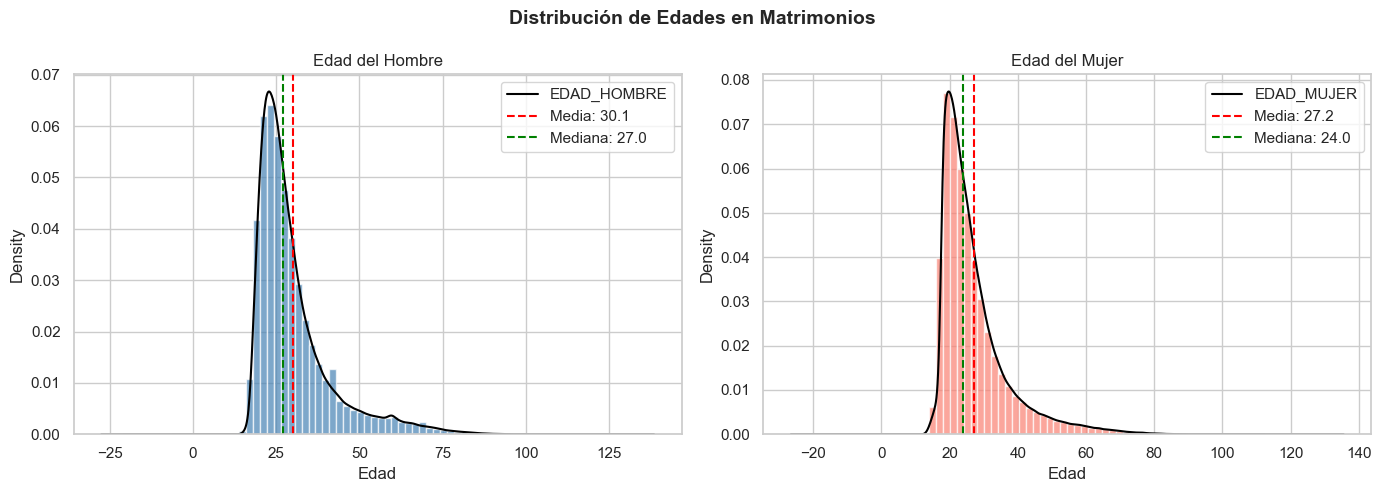

In [7]:
#  Distribución de edades

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Edades en Matrimonios', fontsize=14, fontweight='bold')

for ax, col, color, label in zip(
    axes,
    ['EDAD_HOMBRE', 'EDAD_MUJER'],
    ['steelblue', 'salmon'],
    ['Hombre', 'Mujer']
):
    if col in df_matrimonios.columns:
        data = df_matrimonios[col].dropna()
        ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white', density=True)
        data.plot.kde(ax=ax, color='black', linewidth=1.5)
        ax.axvline(data.mean(),   color='red',   linestyle='--', label=f'Media: {data.mean():.1f}')
        ax.axvline(data.median(), color='green', linestyle='--', label=f'Mediana: {data.median():.1f}')
        ax.set_title(f'Edad del {label}')
        ax.set_xlabel('Edad')
        ax.legend()

plt.tight_layout()
plt.show()

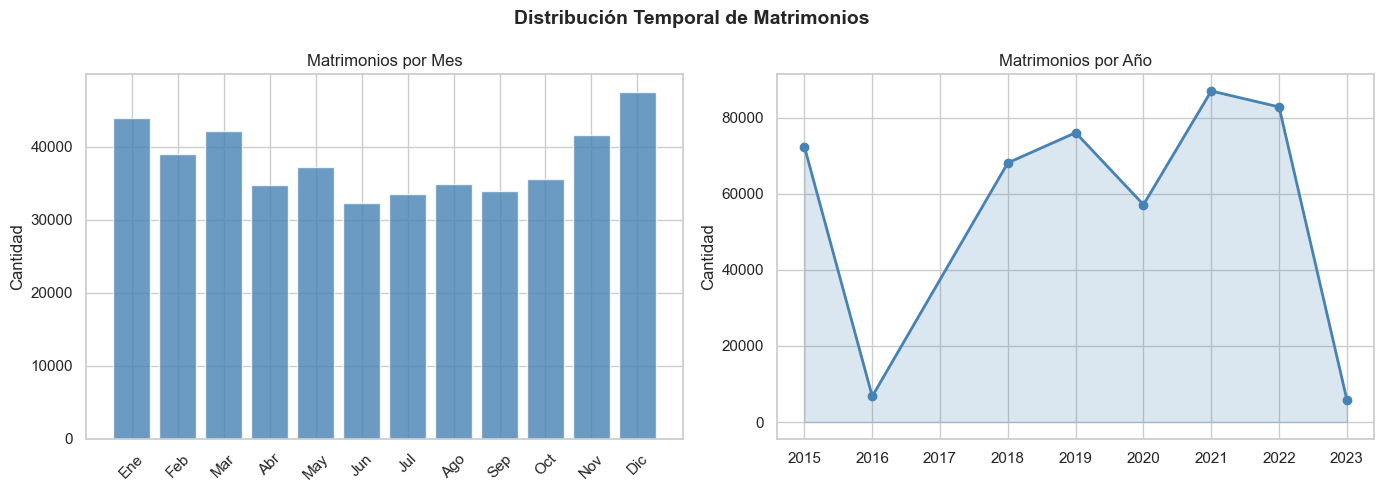

In [8]:
# Distribución temporal

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución Temporal de Matrimonios', fontsize=14, fontweight='bold')

if 'MESREG' in df_matrimonios.columns:
    mes_counts = df_matrimonios['MESREG'].value_counts().sort_index()
    axes[0].bar(mes_counts.index, mes_counts.values, color='steelblue', alpha=0.8, edgecolor='white')
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(meses, rotation=45)
    axes[0].set_title('Matrimonios por Mes')
    axes[0].set_ylabel('Cantidad')

if 'AÑOREG' in df_matrimonios.columns:
    anio_counts = df_matrimonios['AÑOREG'].value_counts().sort_index()
    axes[1].plot(anio_counts.index, anio_counts.values, marker='o', color='steelblue', linewidth=2)
    axes[1].fill_between(anio_counts.index, anio_counts.values, alpha=0.2, color='steelblue')
    axes[1].set_title('Matrimonios por Año')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

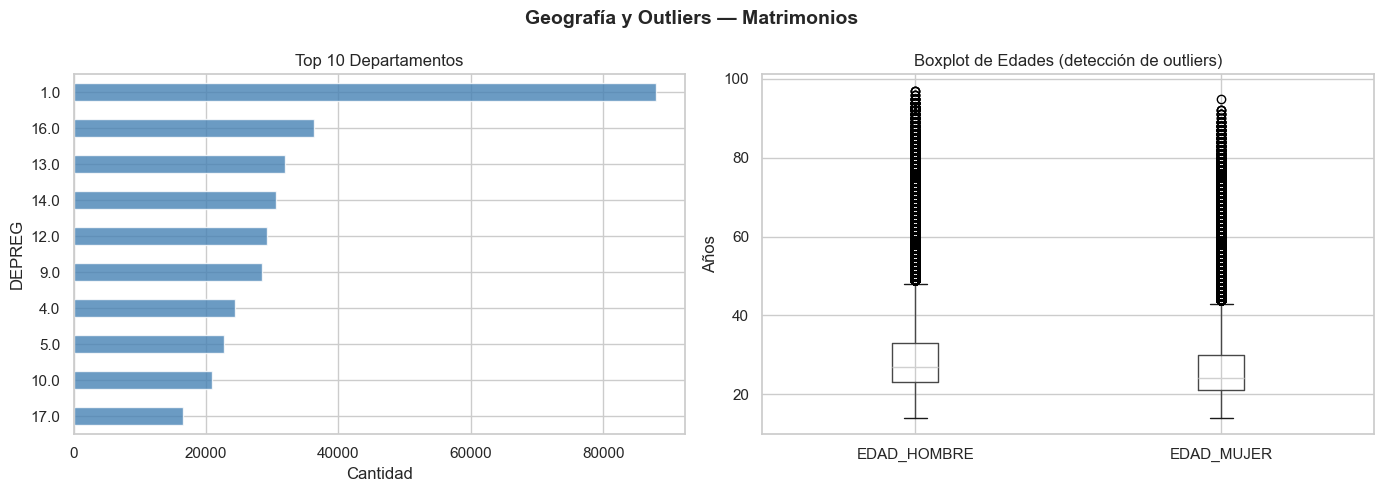

In [9]:

# Distribución geográfica y outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geografía y Outliers — Matrimonios', fontsize=14, fontweight='bold')

# Top departamentos
if 'DEPREG' in df_matrimonios.columns:
    top_dep = df_matrimonios['DEPREG'].value_counts().head(10)
    top_dep.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
    axes[0].set_title('Top 10 Departamentos')
    axes[0].set_xlabel('Cantidad')
    axes[0].invert_yaxis()

# Boxplot edades
cols_box = [c for c in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD']
            if c in df_matrimonios.columns]
if cols_box:
    df_matrimonios[cols_box].boxplot(ax=axes[1])
    axes[1].set_title('Boxplot de Edades (detección de outliers)')
    axes[1].set_ylabel('Años')

plt.tight_layout()
plt.show()

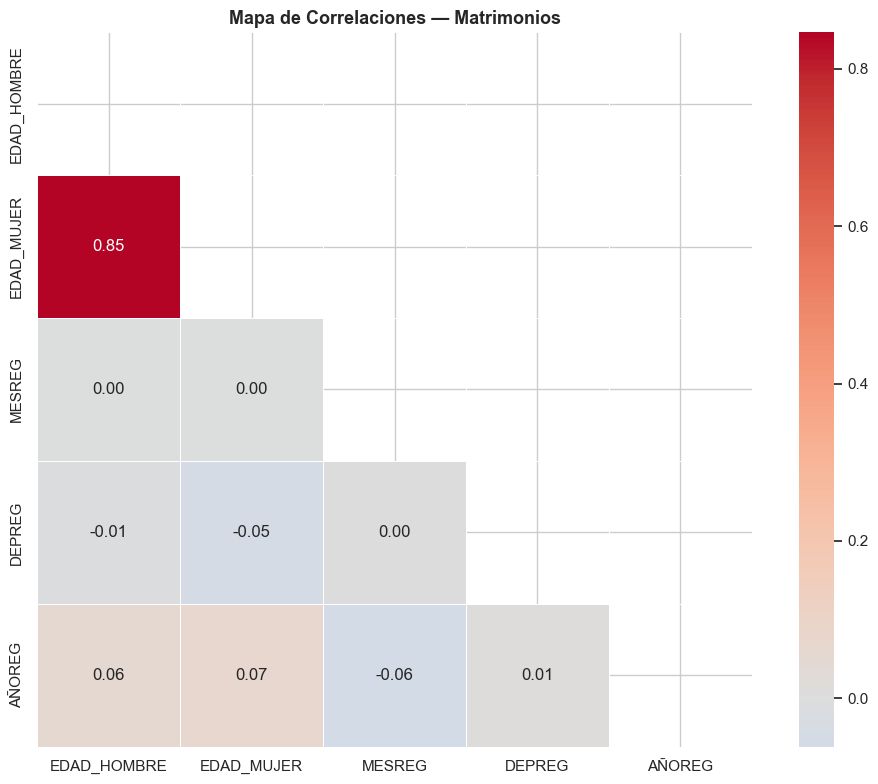

In [10]:
# Mapa de correlaciones

cols_corr = [c for c in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD',
                          'EDAD_PROMEDIO', 'MESREG', 'DEPREG', 'AÑOREG']
             if c in df_matrimonios.columns]

if cols_corr:
    corr = df_matrimonios[cols_corr].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5, square=True)
    ax.set_title('Mapa de Correlaciones — Matrimonios', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [11]:

# Estadisticas descriptivas divorcios

print('EDA DIVORCIOS — Estadisticas Descriptivas\n')

cols_interes_div = [c for c in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD',
                                 'EDAD_PROMEDIO', 'MESREG', 'DEPREG', 'AÑOREG']
                    if c in df_divorcios.columns]

resumen_div = df_divorcios[cols_interes_div].describe().T
resumen_div['skewness'] = df_divorcios[cols_interes_div].skew()
resumen_div['kurtosis'] = df_divorcios[cols_interes_div].kurt()
display(resumen_div[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']].round(2))

EDA DIVORCIOS — Estadisticas Descriptivas



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
EDAD_HOMBRE,8767.0,33.52,5.54,18.0,33.0,33.0,33.0,90.0,2.98,16.52
EDAD_MUJER,8767.0,30.40,5.04,16.0,30.0,30.0,30.0,74.0,2.59,13.53
MESREG,8767.0,6.51,3.40,1.0,4.0,7.0,9.0,12.0,-0.01,-1.17
DEPREG,8767.0,8.17,6.82,1.0,1.0,7.0,14.0,22.0,0.45,-1.12
AÑOREG,8767.0,2015.16,0.37,2015.0,2015.0,2015.0,2015.0,2016.0,1.86,1.45


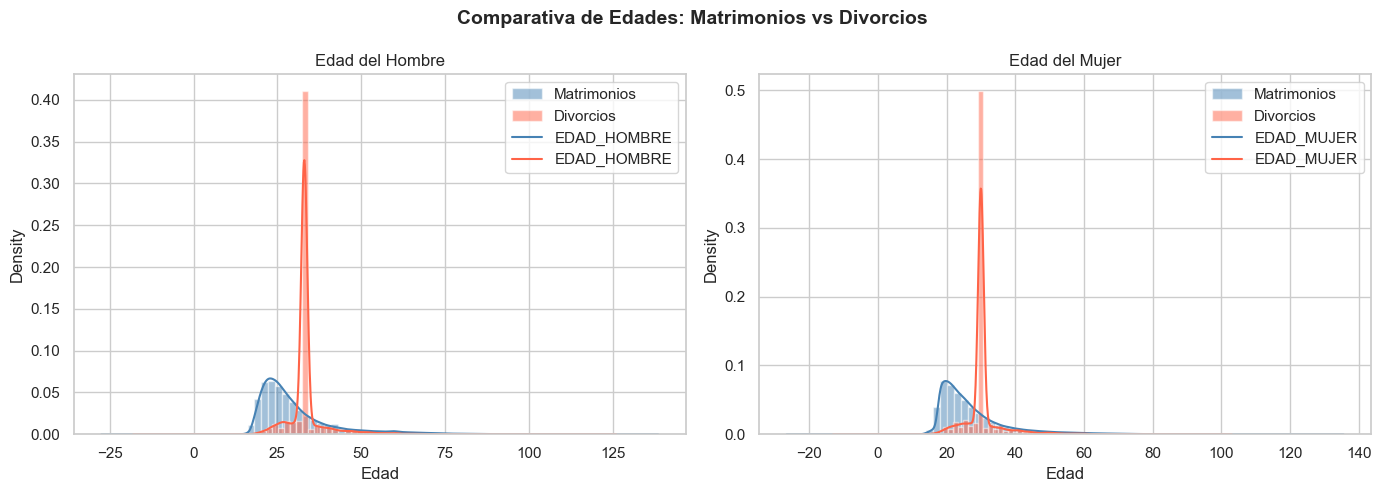

In [12]:
# Comparativa Matrimonios vs Divorcios

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de Edades: Matrimonios vs Divorcios', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes, ['EDAD_HOMBRE', 'EDAD_MUJER'], ['Hombre', 'Mujer']):
    if col in df_matrimonios.columns and col in df_divorcios.columns:
        d_mat = df_matrimonios[col].dropna()
        d_div = df_divorcios[col].dropna()

        ax.hist(d_mat, bins=40, color='steelblue', alpha=0.5, density=True, label='Matrimonios')
        ax.hist(d_div, bins=40, color='tomato',    alpha=0.5, density=True, label='Divorcios')
        d_mat.plot.kde(ax=ax, color='steelblue', linewidth=1.5)
        d_div.plot.kde(ax=ax, color='tomato',    linewidth=1.5)
        ax.set_title(f'Edad del {label}')
        ax.set_xlabel('Edad')
        ax.legend()

plt.tight_layout()
plt.show()

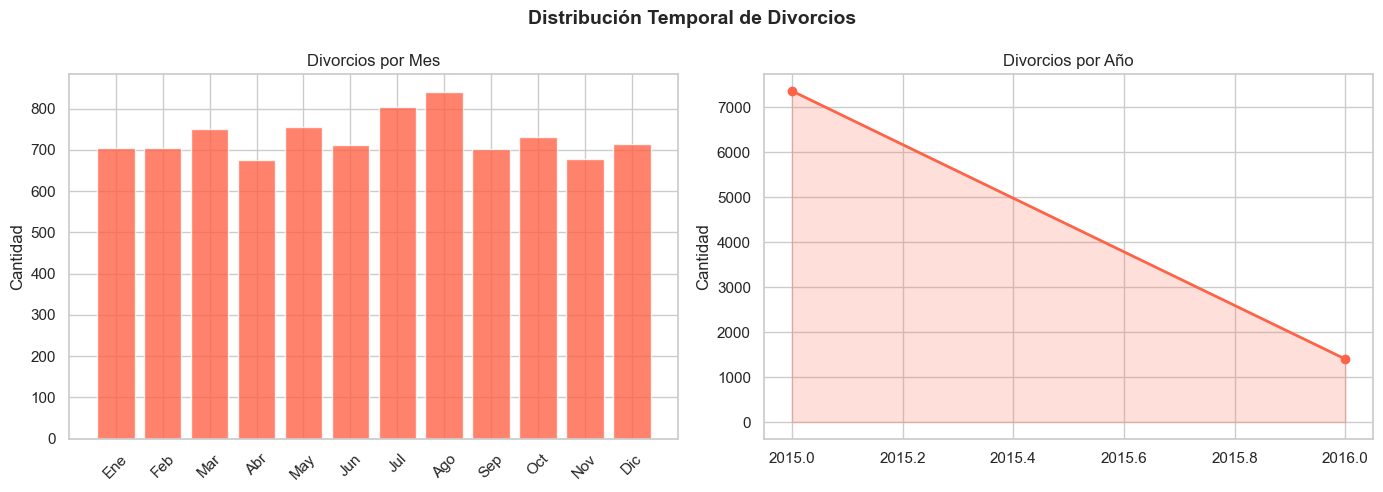

In [13]:

#Distribucion temporal divorcios


meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución Temporal de Divorcios', fontsize=14, fontweight='bold')

if 'MESREG' in df_divorcios.columns:
    mes_counts = df_divorcios['MESREG'].value_counts().sort_index()
    axes[0].bar(mes_counts.index, mes_counts.values, color='tomato', alpha=0.8, edgecolor='white')
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(meses, rotation=45)
    axes[0].set_title('Divorcios por Mes')
    axes[0].set_ylabel('Cantidad')

if 'AÑOREG' in df_divorcios.columns:
    anio_counts = df_divorcios['AÑOREG'].value_counts().sort_index()
    axes[1].plot(anio_counts.index, anio_counts.values, marker='o', color='tomato', linewidth=2)
    axes[1].fill_between(anio_counts.index, anio_counts.values, alpha=0.2, color='tomato')
    axes[1].set_title('Divorcios por Año')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

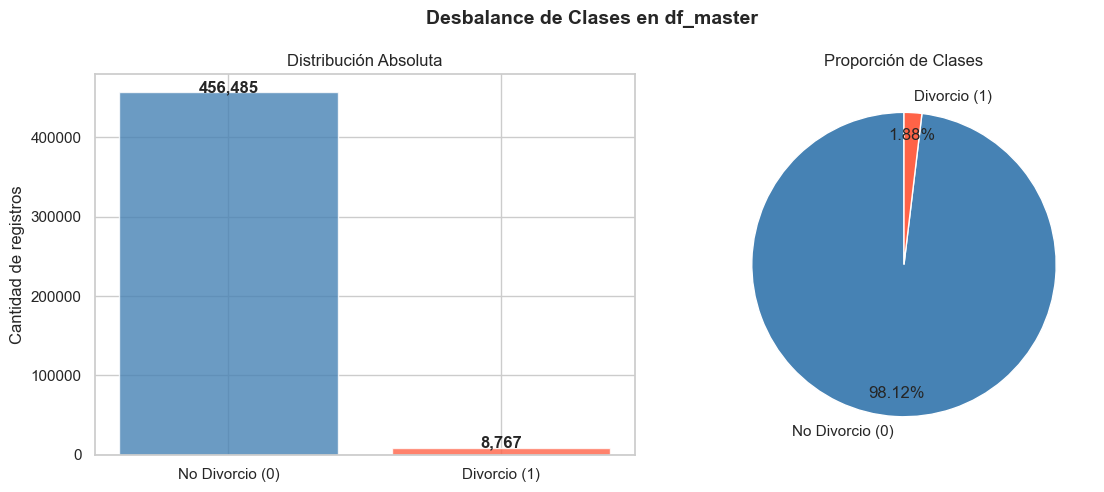


 Ratio de desbalance: 52.1:1


In [14]:

# Desbalance de clases


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Desbalance de Clases en df_master', fontsize=14, fontweight='bold')

conteo  = df_master['DIVORCIO'].value_counts()
labels  = ['No Divorcio (0)', 'Divorcio (1)']
colores = ['steelblue', 'tomato']

bars = axes[0].bar(labels, conteo.values, color=colores, alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución Absoluta')
axes[0].set_ylabel('Cantidad de registros')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 200, f'{val:,}',
                 ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=labels, colors=colores,
            autopct='%1.2f%%', startangle=90, pctdistance=0.85)
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

ratio = conteo.max() / conteo.min()
print(f'\n Ratio de desbalance: {ratio:.1f}:1')


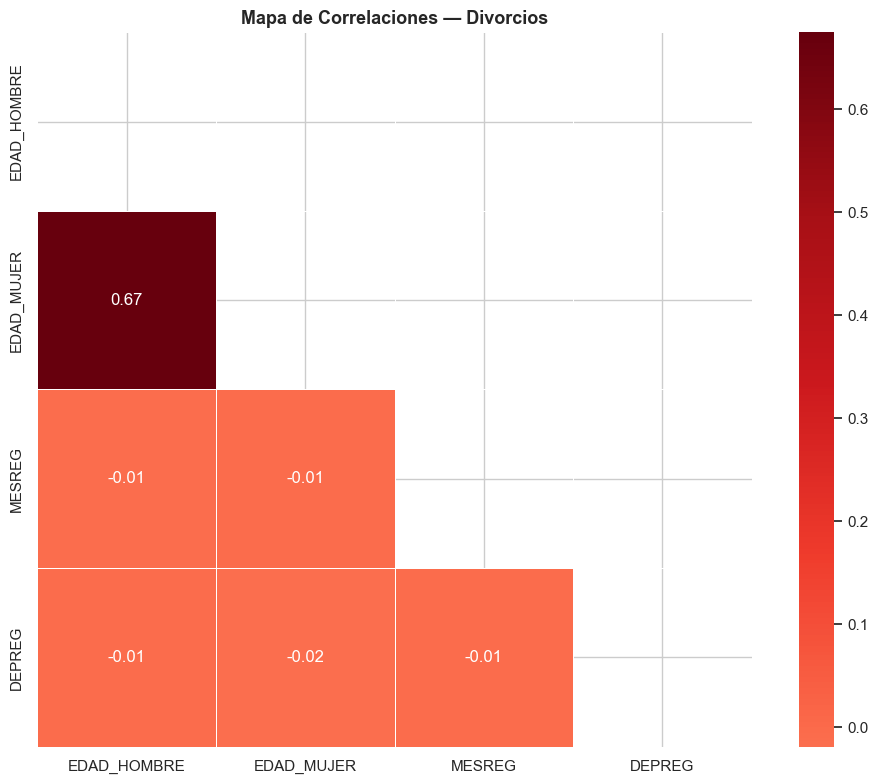

In [15]:

# Correlaciones en divorcios


cols_corr_div = [c for c in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD',
                               'EDAD_PROMEDIO', 'MESREG', 'DEPREG']
                 if c in df_divorcios.columns]

if cols_corr_div:
    corr_div = df_divorcios[cols_corr_div].corr()
    mask = np.triu(np.ones_like(corr_div, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_div, mask=mask, annot=True, fmt='.2f', cmap='Reds',
                center=0, ax=ax, linewidths=0.5, square=True)
    ax.set_title('Mapa de Correlaciones — Divorcios', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [16]:
# ─────────────────────────────────────────────────────────────
#  Imports de modelado
# ─────────────────────────────────────────────────────────────

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        accuracy_score, f1_score,
                                        roc_auc_score, roc_curve)

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_DISPONIBLE = True
    print(' SMOTE disponible')
except ImportError:
    SMOTE_DISPONIBLE = False
    print(' SMOTE no disponible — instala: pip install imbalanced-learn')

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIBLE = True
    print('XGBoost disponible')
except ImportError:
    XGBOOST_DISPONIBLE = False
    print(' XGBoost no disponible — instala: pip install xgboost')

 SMOTE disponible
XGBoost disponible


In [18]:
# ─────────────────────────────────────────────────────────────
# Preparacion y SMOTE
# ─────────────────────────────────────────────────────────────

FEATURES = [f for f in ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD', 'EDAD_PROMEDIO']
            if f in df_master.columns]

df_model = df_master[FEATURES + ['DIVORCIO']].dropna()
X = df_model[FEATURES].values
y = df_model['DIVORCIO'].values

print(f'Features utilizados: {FEATURES}')
print(f'Registros para modelado: {len(df_model):,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

if SMOTE_DISPONIBLE:
    smote = SMOTE(random_state=SEED)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print(f'\n SMOTE aplicado. Nuevo tamaño train: {len(X_train):,}')
    vals, cnts = np.unique(y_train, return_counts=True)
    for v, c in zip(vals, cnts):
        print(f'   Clase {int(v)}: {c:,} ({c/len(y_train)*100:.1f}%)')
else:
    print('\n  Sin SMOTE — se usará class_weight="balanced"')

Features utilizados: ['EDAD_HOMBRE', 'EDAD_MUJER', 'DIFERENCIA_EDAD', 'EDAD_PROMEDIO']
Registros para modelado: 465,252

 SMOTE aplicado. Nuevo tamaño train: 730,374
   Clase 0: 365,187 (50.0%)
   Clase 1: 365,187 (50.0%)


In [20]:
# ─────────────────────────────────────────────────────────────
# Definición y entrenamiento de modelos
# ─────────────────────────────────────────────────────────────

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

cw = None if SMOTE_DISPONIBLE else 'balanced'

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=SEED, class_weight=cw),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                   random_state=SEED, class_weight=cw, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                       max_depth=4, random_state=SEED,
                                                       subsample=0.8),
    # LinearSVC: misma idea que SVM pero O(n) — miles de veces más rápido
    'SVM (Linear)':        CalibratedClassifierCV(
                               LinearSVC(max_iter=2000, random_state=SEED, class_weight=cw)
                           ),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

if XGBOOST_DISPONIBLE:
    modelos['XGBoost'] = XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        eval_metric='logloss', random_state=SEED,
        scale_pos_weight=(1 if SMOTE_DISPONIBLE else 30),
        n_jobs=-1
    )

# Modelos lentos que se saltan el cross-validation
SALTAR_CV = {'KNN', 'SVM (Linear)'}

resultados_lista  = []
modelos_entrenados = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)  # 3 folds, no 5

for nombre, modelo in modelos.items():
    print(f'   Entrenando: {nombre}...')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_div = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = round(roc_auc_score(y_test, y_proba), 4)
    except Exception:
        auc = 'N/A'

    # CV solo en modelos rápidos
    if nombre not in SALTAR_CV:
        cv_scores = cross_val_score(modelo, X_train, y_train,
                                     cv=cv, scoring='f1_macro', n_jobs=-1)
        cv_mean = round(cv_scores.mean(), 4)
        cv_std  = round(cv_scores.std(),  4)
    else:
        cv_mean, cv_std = 'N/A', 'N/A'

    resultados_lista.append({
        'Modelo':       nombre,
        'Accuracy':     round(acc,    4),
        'F1 Macro':     round(f1,     4),
        'F1 Divorcio':  round(f1_div, 4),
        'AUC-ROC':      auc,
        'CV F1 (mean)': cv_mean,
        'CV F1 (std)':  cv_std,
    })
    modelos_entrenados[nombre] = (modelo, y_pred)
    print(f'     - ACC={acc:.4f} | F1 Divorcio={f1_div:.4f} | AUC={auc}')

df_resultados = pd.DataFrame(resultados_lista)
print('\n----- Todos los modelos entrenados-----')
display(df_resultados)

   Entrenando: Regresión Logística...
     - ACC=0.7154 | F1 Divorcio=0.0996 | AUC=0.7548
   Entrenando: Random Forest...
     - ACC=0.9765 | F1 Divorcio=0.5423 | AUC=0.9164
   Entrenando: Gradient Boosting...
     - ACC=0.9678 | F1 Divorcio=0.4663 | AUC=0.9162
   Entrenando: SVM (Linear)...
     - ACC=0.7144 | F1 Divorcio=0.0992 | AUC=0.7545
   Entrenando: KNN...
     - ACC=0.9916 | F1 Divorcio=0.7569 | AUC=0.8578
   Entrenando: XGBoost...
     - ACC=0.9744 | F1 Divorcio=0.5225 | AUC=0.9172

----- Todos los modelos entrenados-----


,Modelo,Accuracy,F1 Macro,F1 Divorcio,AUC-ROC,CV F1 (mean),CV F1 (std)
0,Regresión Logística,0.7154,0.4653,0.0996,0.7548,0.7749,0.0005
1,Random Forest,0.9765,0.7651,0.5423,0.9164,0.8679,0.0009
2,Gradient Boosting,0.9678,0.7248,0.4663,0.9162,0.8829,0.0012
3,SVM (Linear),0.7144,0.4647,0.0992,0.7545,N/A,N/A
4,KNN,0.9916,0.8763,0.7569,0.8578,N/A,N/A
5,XGBoost,0.9744,0.7547,0.5225,0.9172,0.8818,0.0015
